## 第3章：注意力机制 ##

### 3.1 长序列建模中的问题

早期做序列到序列任务（比如把德语翻译成英语）时，常见的做法是用**循环神经网络（RNN）**。RNN读输入句子的时候，会把看到的信息不断写进一个“当前状态”里。等它把整句话读完，才开始生成输出。也就是说，在真正开始输出之前，它需要把整段输入尽量压缩成一个中间状态，可以把它理解成对输入的一种摘要或潜在表示。之后模型在生成每个输出**词元（token）** 时，就主要依赖这个中间状态一步步写下去。（此过程大致了解即可）

这种方式的问题在于，翻译时如果只能靠一个被压缩过的中间状态，而不能随时回看完整输入，就很容易丢掉细节。信息一旦在压缩过程中损失，后面生成输出时就无法补回来，翻译结果就可能不够理想，尤其是句子较长或结构更复杂的时候更明显。

### 3.2 使用注意力机制捕捉数据依赖关系

**自注意力机制（Self-attention）** 想解决的就是这个问题。它的核心想法是，当模型在生成文本的每一步时，不必只依赖一个压缩后的摘要，而是可以随时查看整个输入句子，并从中挑出对当前生成最有帮助的部分。换句话说，在生成某个输出token时，模型仍然能够访问所有输入token，而不是被限制在一个固定的中间表示里。

用翻译来举例，输入是 “Kannst du mir ……” ，目标输出是 “can you help …”。假设模型已经生成了第一个输出“can”，现在正在生成第二个输出“you”。在这一刻，模型不仅可以参考已经生成的“can”，也可以同时查看输入句子里的所有token。更重要的是，模型不会把每个输入token都当成同等重要，而是会根据“我现在要生成的是哪个输出token”，给不同的输入token分配不同的重要程度。


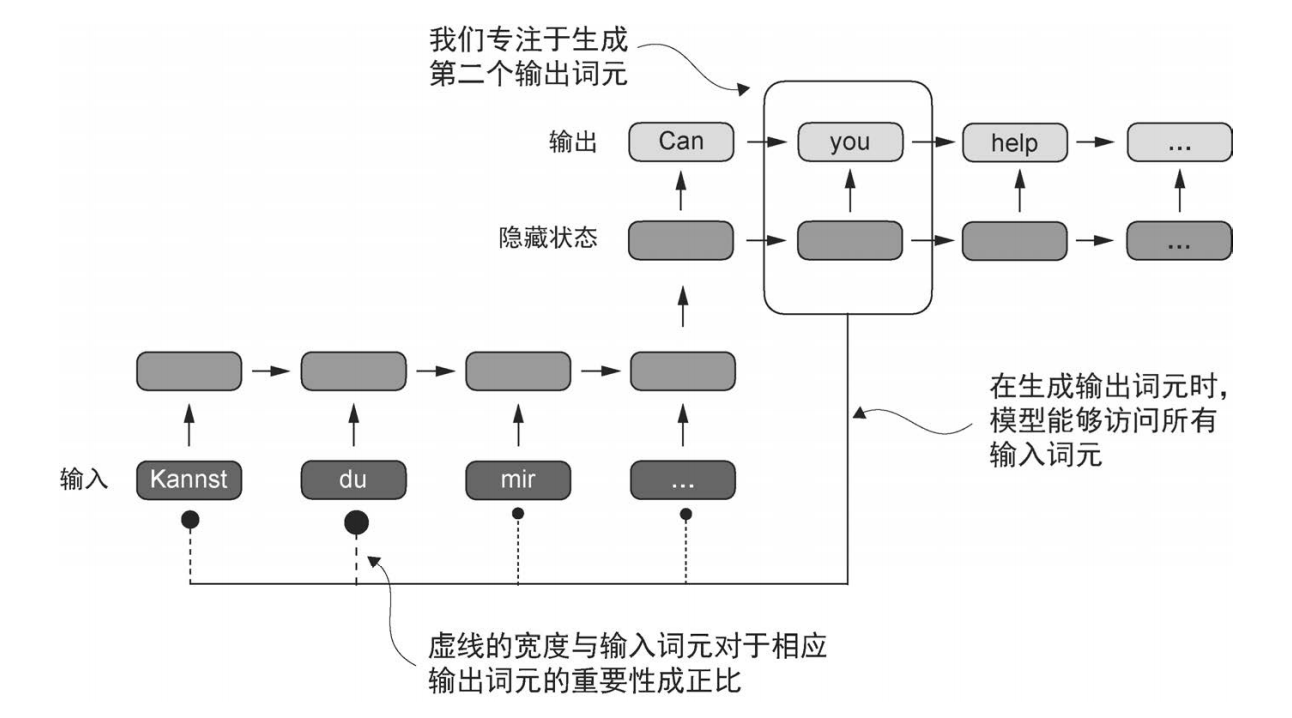

比如在生成“you”时，输入中的“du”与“you”直接对应，所以它对当前这一步特别关键，模型就会给它更高的权重。其他与当前生成关系不那么强的输入词元，权重就会更低。这样的权重就是注意力分数或注意力权重，它们表示模型在这一时刻更应该从哪些输入词元获取信息、更应该忽略哪些。

因此，自注意力机制带来的直观变化是，模型在生成文本时可以“回看整个输入”，而且是“有选择地回看”。这也说明了为什么当用户提出问题时，模型在生成回答的任意时刻都能引用完整输入，而不需要完全依赖一个固定的中间摘要。


### 3.3 通过自注意力机制关注输入的不同部分

在上一章节已经完成预处理的基础上，接下来这一章要介绍的就是这种自注意力模块，它让模型能够在生成过程中访问全部输入，并学会为不同输入分配不同的重要性。


在更“微观”的层面，自注意力这一部分想做的事情，其实是把输入序列从“每个词各自的向量表示”，转换成“每个词都带着上下文信息的新向量表示”。可以把它理解成一次信息融合。融合之后得到的向量，既保留了当前位置这个词本身的含义，也吸收了句子里其他词对它的补充信息，所以常被叫作**上下文向量（context vector）**。

以句子 “your journey starts … step” 为例。我们先把句子分成词元，然后把每个词元变成一个嵌入向量。图里为了好理解，把每个向量简化成只有三个数，比如第一个词是 $x^{(1)}$，第二个词是 $x^{(2)}$，一直到第 T 个词是 $x^{(T)}$。到这里为止，我们已经有了一串向量，形状上可以理解为“T个位置，每个位置一个向量”。

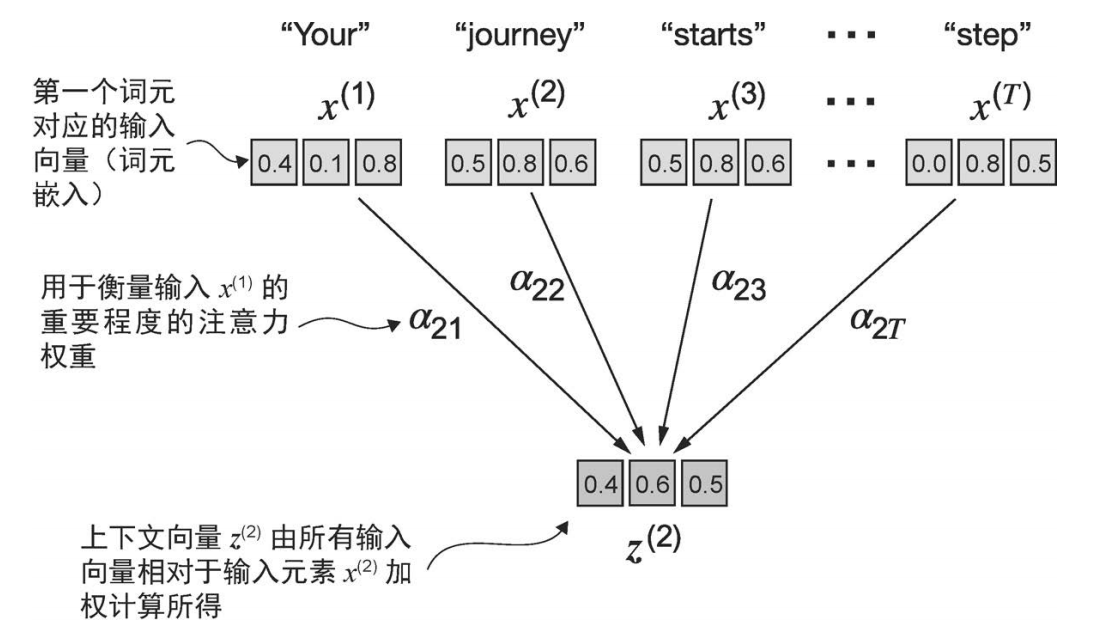

接下来我们选择序列中的某一个位置，图里重点关注第二个词 “journey”。我们的目标是为它生成一个新的向量 $z^(2)$。之所以叫上下文向量，是因为它不是只由 “journey” 自己决定，而是把整个输入序列都纳入考虑，只是不同词元对它的贡献大小不同。

这种“贡献大小”就是注意力权重 α。当我们为第二个词生成上下文向量时，会得到一组权重 
$α_{21}$ ,$α_{22}$ ,…,$α_{2T}$ 。它们分别表示在构造 $z^(2)$ 时，第1个输入向量$x^{(1)}$ 的贡献有多大，第2个输入向量$x^{(2)}$的贡献有多大，一直到第T个输入向量$x^{(T)}$ 的贡献有多大。


有了这组权重之后，上下文向量就是对所有输入向量做一次加权求和：

$$
z^{(2)} = \sum_{j=1}^{T} \alpha_{2j}\, x^{(j)}
$$


正因为是“加权求和”，所有词元都会参与，只是权重可能很小。回到翻译的例子，生成 “you” 时，“du” 往往会得到更高权重，但其他词也不会完全消失，只是贡献更弱。

那么这些权重 $α_{2j}$  是怎么来的。我们需要一个 **“参考”（query）**，例子中用 “journey” 进行表示，然后模型会把这个查询和每一个输入向量做相似度比较，常见的比较方式就是点积。点积越大，表示越相关，后续就会给它更高的权重，再把这些相似度分数转换成一组可以用来加权的权重（下文会具体进行讲解）。

我们先从一个已经准备好的张量开始。句子是 “Your journey starts with one step”。为了便于理解，这里假设每个单词都是一个 token。对每个 token，我们都已经有了一个对应的**嵌入向量（embedding）**，并且为了简化演示，每个嵌入向量只有 3 个数，也就是一个三维向量。

接下来，我们把这 6 个单词的嵌入向量按顺序堆叠成一个二维张量 inputs。这个张量可以理解为“一个句子的向量表示”，其中每一行对应句子中的一个单词。

In [31]:
import torch 
inputs = torch.tensor( 
 [[0.43, 0.15, 0.89], # Your (x^1) 
 [0.55, 0.87, 0.66], # journey (x^2) 
 [0.57, 0.85, 0.64], # starts (x^3) 
 [0.22, 0.58, 0.33], # with (x^4) 
 [0.77, 0.25, 0.10], # one (x^5) 
 [0.05, 0.80, 0.55]] # step (x^6) 
)

注意力权重通常来自对“当前位置”和“序列中其他位置”之间相关性的度量。最常见的做法是用点积来计算相似度分数（score），两个向量的点积越大，通常表示它们在当前表示空间里越相关，后续就会在归一化后得到更高的注意力权重。

在这个示例里，我们想为单词 “journey” 计算对应的上下文向量。为了做到这一点，我们先把 “journey” 的输入嵌入向量取出来，作为当前步骤的参考向量。由于 PyTorch 的索引从 0 开始，句子中第二个单词对应的行索引是 1，所以可以通过 inputs[1] 取到 “journey” 的向量。

In [36]:
input_query = inputs[1] #由于 PyTorch 的索引从 0 开始，句子中第二个单词对应的行索引是 1，
                        #所以可以通过 inputs[1] 取到 “journey” 的向量。
input_query

tensor([0.5500, 0.8700, 0.6600])

现在我们再取出句子中另一个token，比如第一个单词 “Your”。

In [37]:
input_1 = inputs[0]
input_1

tensor([0.4300, 0.1500, 0.8900])

点积的计算方式是把两个向量在同一维度上的元素一一对应相乘，然后把所有乘积相加。也就是说，如果用最直接的手算方式，就是用 input_query 的第一个元素乘以 input_1 的第一个元素，再用第二个元素相乘，依此类推，最后把这些结果全部加起来，得到一个标量作为点积结果。

In [33]:
0.55*0.43 + 0.87*0.15 + 0.66*0.89

0.9544

在 PyTorch 中，我们不需要手动逐元素相乘再相加，可以直接使用 torch.dot 来计算两个一维向量的点积。只要 `input_query` 和 `input_1` 都是一维张量并且长度相同（这里都是长度为 3），下面这行代码就会返回它们的点积结果，并且与手工计算得到的标量一致。

In [39]:
torch.dot(input_query,input_1)

tensor(0.9544)

我们可以对序列中的任意输入向量都用同样的方法处理：对于每个 `inputs[i]`，将它的各个维度与 `input_query` 对应维度逐一相乘，并把所有乘积累加起来，就得到这两个向量的点积。可以看到，这样计算出的结果与之前直接使用点积函数得到的结果是一致的。

In [40]:
res = 0. #先准备一个“从 0 开始的计数器”，用来把后面每一步算出来的值不断加进去，小数形式
i = 0

for idx, ele in enumerate(inputs[i]):  #遍历 inputs[i] 向量中的每个元素，同时获得该元素的索引 idx 和对应的数值 ele。
    res += inputs[i][idx] * input_query[idx]
res

tensor(0.9544)

或者是用更简单的写法也能得到相同的结果。

In [43]:
res = 0.
i = 0

res = torch.dot(inputs[i],input_query)
res

tensor(0.9544)

前面我们通过修改 i 的取值，分别计算了 inputs[i] 与 input_query 的点积。为了避免每次都手动改动 i，我们可以写一个循环，让程序一次性对序列中的所有 token 向量都执行同样的操作。

具体做法是：固定查询向量 query（这里选 “journey” 的向量），然后依次取出 inputs 中的每一行向量 x_i，计算 x_i 与 query 的点积，并把结果存入一个长度等于 token 数量的张量中。最终得到的一组数就是查询向量与所有输入向量的相似度分数（注意力分数）。

In [51]:
query = inputs[1]  #针对journey计算注意力权重

attn_scores_2 = torch.empty(inputs.shape[0]) #创建的是“未初始化”的张量，里面的数一开始都是0.
                                             #随后会在循环里把每个位置替换成每个输入向量与query的点积结果
for i, x_i in enumerate(inputs): 
    attn_scores_2[i] = torch.dot(x_i, query) 
    
print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


现在我们已经得到了这组注意力分数，下一步就是把它们转换成注意力权重。这样做的目的，是把原本大小不受限制的分数进行规范化处理，使它们变得更稳定、更便于比较和使用。经过规范化之后，数值通常会落在更合适的范围内，也更有利于后续的计算与优化。

把分数转换为权重有多种做法。最直观的一种方法是先计算所有分数的总和，然后让每个分数除以这个总和，从而得到一组归一化后的权重。下面我们先用代码实现这种简单的归一化方式。

In [52]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum() 

print("Attention weights:", attn_weights_2_tmp) 
print("Sum:", attn_weights_2_tmp.sum())

Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


在实际应用中，使用 softmax 函数进行归一化更为常见，而且是一种更可取的做法。这种方法更好地处理了极值，并在训练期间提供了更有利的梯度特性。下面为了演示 softmax 的基本计算方式，我们手动实现一个朴素版本（仅用于理解；在实际训练中通常会使用更稳定的实现）。

In [53]:
def softmax_naive(x): 
    return torch.exp(x) / torch.exp(x).sum(dim=0) 

attn_weights_2_naive = softmax_naive(attn_scores_2) 

print("Attention weights:", attn_weights_2_naive) 
print("Sum:", attn_weights_2_naive.sum())


Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


可以看到，这里用 softmax 得到的注意力权重与前面采用“除以总和”的归一化方式相比会有一些细微差别。两者整体趋势往往相近，但在训练神经网络并进行优化时，softmax 通常具有更好的数值性质和更合适的权重分配方式，因此在实践中更常用。

但在某些特定去之下，上述方案会失效或者不稳定，因此在实际工程中也更推荐直接使用 PyTorch 提供的 softmax 函数来实现这一过程。

In [59]:
attn_weights_2 = torch.softmax(attn_scores_2,dim=0) #一维张量只有一个方向可选，它的维度编号就是 0

接下来我们回到输入向量序列。对于每一个输入向量，我们将它与对应的注意力权重相乘，得到加权后的向量。然后将这些向量相加，便得到了上下文向量。

In [85]:
query = inputs[1] 

context_vec_2 = torch.zeros(query.shape)

for i,x_i in enumerate(inputs): 
    context_vec_2 += attn_weights_2[i]*x_i 
    print(f"{inputs[i]} ---> {attn_weights_2[i]}")
    
print( "上下文向量=", context_vec_2)

tensor([0.4300, 0.1500, 0.8900]) ---> 0.13854756951332092
tensor([0.5500, 0.8700, 0.6600]) ---> 0.2378913015127182
tensor([0.5700, 0.8500, 0.6400]) ---> 0.23327402770519257
tensor([0.2200, 0.5800, 0.3300]) ---> 0.12399158626794815
tensor([0.7700, 0.2500, 0.1000]) ---> 0.10818186402320862
tensor([0.0500, 0.8000, 0.5500]) ---> 0.15811361372470856
上下文向量= tensor([0.4419, 0.6515, 0.5683])


现在我们需要把这个过程推广到整个序列。前面我们只为第二个输入向量计算了注意力权重，接下来要对序列中的每一个输入向量都重复同样的步骤，分别计算各自对应的注意力权重。

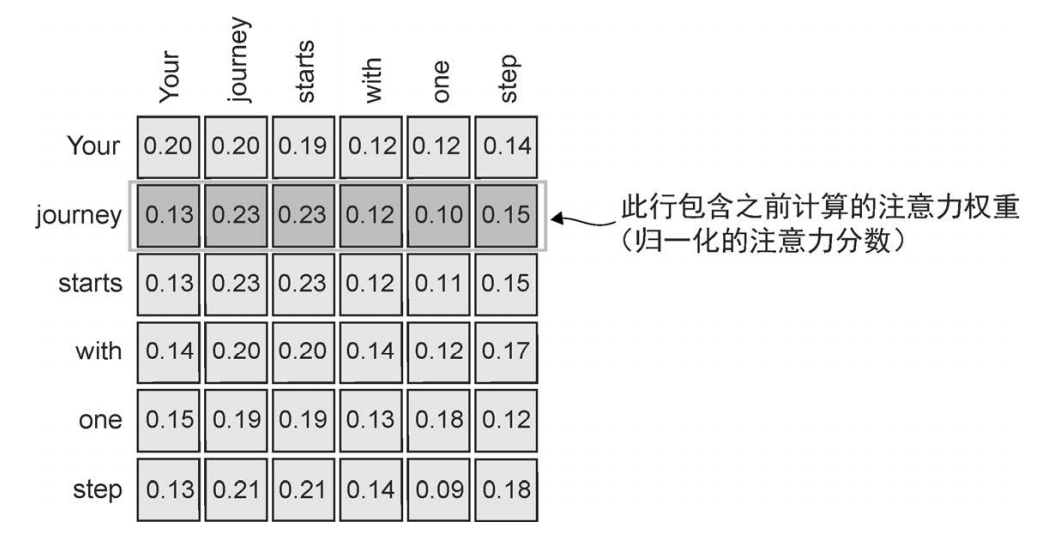

现在我们需要使用一个双重 for 循环来完成计算，因为要得到注意力分数矩阵，就必须计算序列中任意两个输入向量之间的点积。也就是说，对每一个$x_i$，都要依次与所有$x_j$计算点积。按这样的方式遍历所有i和j，就可以得到一个完整的注意力分数矩阵。

In [86]:
attn_scores = torch.empty(6,6) #初始化注意力分数矩阵，如上图所示是一个6x6的矩阵

for i, x_i in enumerate(inputs): 
    for j, x_j in enumerate(inputs): 
        attn_scores[i,j] = torch.dot(x_i, x_j) 
    
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


前面我们通过双重循环计算任意两个输入向量的点积，从而得到注意力分数矩阵。更高效的做法是直接使用矩阵乘法，将所有token向量按行组成矩阵inputs后，利用 `inputs @ inputs.T`即可一次性得到全部两两点积分数。在PyTorch中，循环实际上非常慢，而矩阵乘法会调用高度优化的底层实现。

In [87]:
attn_scores = inputs @ inputs.T  #矩阵乘法
attn_scores

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

接下来我们要把注意力分数矩阵进行归一化，得到注意力权重矩阵。我们使用softmax来完成这一过程，并指定`dim=1`，表示沿着每一行进行归一化。这样做的效果是：对于矩阵中的每一行，softmax输出的权重之和等于1。

现在`attn_scores`是一个矩阵，形状是 [6,6]，第 0 维（dim=0）对应“行”的方向（上下方向），第 1 维（dim=1）对应“列”的方向（左右方向）。

In [92]:
attn_weights = torch.softmax(attn_scores,dim=1)
attn_weights

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

现在我们已经得到注意力权重矩阵，就可以进一步计算上下文向量。同样地，这一步也可以用矩阵乘法一次性完成。由于每个上下文向量本质上都是对所有输入向量的加权求和，我们可以直接将注意力权重矩阵与输入向量矩阵相乘，从而同时得到序列中每个 token 的上下文向量。

In [93]:
all_context_vecs = attn_weights @ inputs
all_context_vecs

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])

实际上，这个简化版自注意力模块只需要几行代码就能实现：先用矩阵乘法得到所有 token 之间的点积分数（注意力分数矩阵），再用 softmax 在每一行上做归一化得到注意力权重，最后用权重对输入向量做加权求和（同样用矩阵乘法一次性完成），从而得到每个 token 的上下文向量。

In [108]:
attn_scores = inputs @ inputs.T
attn_weights = torch.softmax(attn_scores,dim=1)
all_context_vecs = attn_weights @ inputs
all_context_vecs

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])

为便于教学，我们先实现了一个极简的自注意力版本。接下来会引入更接近真实模型的做法，即**加入可训练参数**，这些参数会在训练过程中被优化，从而学到更合适的注意力分配并提升输出质量。

### 3.4 实现带可训练权重的自注意力机制

在实际自注意力中，输入不会直接彼此点积，而是先通过三组可训练矩阵$W_Q$,$W_K$,$W_V$生成 query、key、value。之后流程不变，用 query与key得到注意力分数，归一化为权重，再对value加权求和得到上下文向量。引入这些矩阵后，上下文向量的维度也由矩阵设定决定，不必与输入向量维度完全相同。

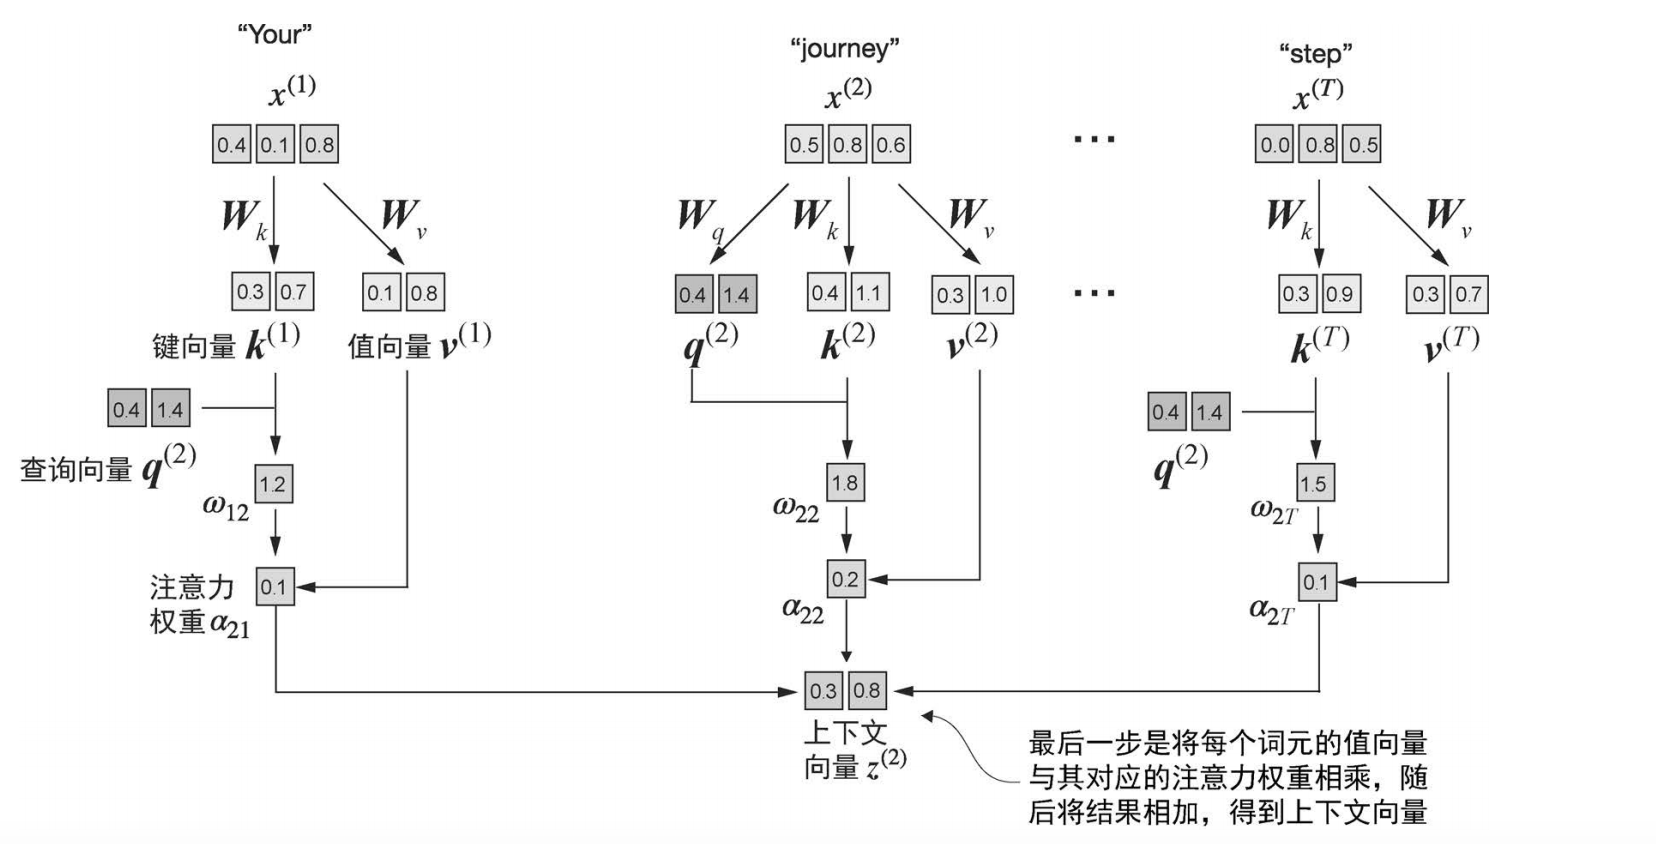

`inputs`是我们在前面步骤中已经构建好的输入张量，里面存放了句子中每个token的三维嵌入向量。

In [109]:
inputs

tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])

我们先将当前需要使用的输入向量赋给一个临时变量作为后续计算的引用，同时定义两个维度参数`d_in`和`d_out`，分别表示输入向量的维度和目标输出维度，以便后续构建和使用相应的权重矩阵。

In [110]:
x_2 = inputs[1]            #取索引为1的嵌入向量，和之前一致为journey
d_in = inputs.shape[1]     #输入维度：每个token向量包含的数值
d_out = 2                  #输出维度：后续要把d_in维映射到的目标维度（教学目的设置为2） 

接下来我们需要生成可训练的权重参数。为了便于复现实验结果，我会先固定随机种子（seed），这样你运行代码时就能得到与示例一致的随机数。随后我们使用PyTorch的随机函数按指定形状生成权重矩阵，例如为query生成一个形状为3×2的矩阵。这个矩阵的数值初始为随机值，训练时会被持续更新，从而学习到更合适的参数。实际实现中通常会将该矩阵封装为`torch.nn.Parameter`，使其被PyTorch明确标记为可训练参数并自动参与优化过程。

In [111]:
torch.manual_seed(123)

W_query = torch.nn.Parameter(torch.rand(d_in,d_out)) #把张量变成模型权重，让它在训练中自动参与梯度计算并被优化器更新
W_query

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]], requires_grad=True)

`requires_grad=True`表示该张量会参与反向传播计算梯度，因此在训练时可以被优化器更新。

同样地，我们接下来定义用于生成 key 和 value 的权重参数。

In [112]:
W_key = torch.nn.Parameter(torch.rand(d_in,d_out))
W_value = torch.nn.Parameter(torch.rand(d_in,d_out))

接下来我们开始计算query向量。我们以第二个 token（“journey”）为例，先取出它的输入嵌入向量`x_2`。然后用权重矩阵`W_query`对它做一次矩阵乘法。这个操作本质上是一个线性变换,把原本的三维输入嵌入映射到二维空间，因此输出得到一个二维的query向量query_2。

In [113]:
query_2 = x_2 @ W_query
query_2

tensor([0.4306, 1.4551], grad_fn=<SqueezeBackward4>)

`grad_fn`表示它会参与反向传播计算梯度。

Query会针对当前要处理的token使用同一套投影方式生成，而key和value则由每个位置的输入向量分别计算得到，因而对不同token是不同的。为了一次性得到所有位置的key和value，我们通常对整个输入矩阵进行矩阵乘法。

In [114]:
keys = inputs @ W_key
values = inputs @ W_value

接下来我们要计算注意力分数。之前的简化版本是用输入向量之间的点积得到分数；现在在更标准的做法中，我们改为通过 query 与 key 的点积来计算注意力分数。

In [116]:
keys_2 = keys[1]
attn_score_22 = torch.dot(query_2, keys_2) #第二个输入相对于第二个输入作为query

attn_score_22

tensor(1.8524, grad_fn=<DotBackward0>)

现在也需要对其他的部分进行同样的操作，也可以用矩阵乘法来实现。

In [119]:
attn_scores_2 = query_2 @ keys.T
attn_scores_2

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440],
       grad_fn=<SqueezeBackward4>)

接下来我们要把注意力分数转换成归一化后的注意力权重，做法与之前一致，仍然使用softmax函数。注意这里会多一步“缩放”处理，因为 key的向量维度是2，我们会在将分数送入softmax之前，用 $\sqrt{d_k}$ 进行缩放，其中$d_k$=2。也就是说，我们先计算$\sqrt{2}$，把注意力分数除以这个值，再做softmax得到最终的注意力权重。

维度越大，点积的数值通常会变得越大。如果不做缩放，注意力分数会更容易出现“差距很大”的情况，softmax就会变得非常极端（几乎全压在某一个位置上），从而梯度变小、训练不稳定。
用$\sqrt{d_k}$去除（缩放）就是把分数的尺度“拉回正常范围”，让softmax的输出不过于尖锐，训练更稳定、优化更容易。

In [124]:
d_k = keys.shape[1]

attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1) #沿着张量的最后一个维度做 softmax。

attn_weights_2

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820],
       grad_fn=<SoftmaxBackward0>)

在注意力里，我们希望对“同一个query对所有key的分数”做归一化，让这些权重加起来等于1。这个“所有 key”的那一维通常就放在最后一维，所以常写成`dim=-1`，这样不管张量是一维、二维还是更高维，都能保持代码通用。

现在我们已经得到了注意力权重，下一步就是计算上下文向量。与之前类似，上下文向量仍然是对一组向量的加权和，只是这里不再直接对原始输入嵌入加权，而是对由输入映射得到的中间表示进行加权。

具体来说，我们使用注意力权重对 value 向量进行加权求和，value 在与注意力权重相乘并累加的过程中，最终形成对应位置的上下文向量。

In [125]:
context_vec_2 = attn_weights_2 @ values

context_vec_2

tensor([0.3061, 0.8210], grad_fn=<SqueezeBackward4>)

现在我们已经能够为第二个输入计算对应的上下文向量，下一步是将同样的计算推广到序列中的所有输入位置。

为便于复用和避免在 Jupyter Notebook 中分散编写多段代码，我们将把前面实现的步骤封装到一个自注意力模块中。具体做法是定义一个继承自 PyTorch 的类，用它来集中管理计算逻辑与参数。

此前定义的权重矩阵会放在类的构造函数`(__init__)`里进行初始化，并通过`self`绑定到对象上，确保在创建模块实例时这些参数能够被正确保存和复用。

随后，在`forward`方法中实现前向计算流程：根据输入计算注意力分数，得到注意力权重，并据此计算上下文向量。这样一来，我们只需要调用一次`forward`，就能对所有输入位置完成自注意力计算。

In [128]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):   #这是一个 PyTorch模块（nn.Module），用于封装自注意力的参数和计算过程

    def __init__(self, d_in, d_out): # __init__ 是“构造函数”：创建这个类的实例时会自动执行
        super(). __init__()          # super().__init__() 会初始化 nn.Module 的内部机制
        self.W_query = torch.nn.Parameter(torch.rand(d_in,d_out))
        self.W_key = torch.nn.Parameter(torch.rand(d_in,d_out))
        self.W_value = torch.nn.Parameter(torch.rand(d_in,d_out))
                                     # self.xxx，相当于把它保存为“这个模块的成员”，后面 forward里也能用

    def forward(self,x):             # 当你调用 module(x)时，PyTorch会自动去调用 forward(x)
        queries = inputs @ W_query
        keys = inputs @ W_key
        values = inputs @ W_value

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / d_k**0.5, dim=-1)
        context_vec = attn_weights @ values
        return context_vec

In [127]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out) #d_in, d_out 用来确定权重矩阵的大小
sa_v1(inputs)

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)

除了手动创建`Parameter`矩阵之外，更常见也更规范的实现方式是使用PyTorch的线性层`nn.Linear`。线性层本质上包含一个可训练的权重矩阵，并且通常还带有一个偏置项（bias）。在自注意力的Q/K/V投影中，偏置是否使用取决于具体模型,为了对齐一些实现，我们可以将 bias=False，只保留权重矩阵。也有模型会保留bias，例如早期的GPT-2采用过带偏置的线性层实现，因此这属于实现选择而非固定规则。

将手动参数替换为`nn.Linear`的另一个优势是初始化更合理。使用`torch.rand`直接生成随机小数虽然能工作，但初始化并未考虑输入输出维度的尺度；而`nn.Linear`通常会采用更合适的权重初始化策略，使参数的初始分布与层的尺寸相匹配，从而在训练开始阶段带来更稳定、更好的优化动态。

In [162]:
import torch.nn as nn

class SelfAttention_v2(nn.Module):  
    
    def __init__(self, d_in, d_out, qkv_bias=False): 
        super(). __init__()          
        self.W_query = torch.nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = torch.nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = torch.nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self,x):             
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / d_k**0.5, dim=-1)
        context_vec = attn_weights @ values
        return context_vec

In [163]:
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out) 
sa_v2(inputs)

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)

当前这些数值看起来比较“奇怪”，主要原因是权重矩阵还处于随机初始化阶段，此时输出并不需要具备可解释的语义；它只是训练的起点。随着训练进行，反向传播会根据损失函数计算梯度并更新这些可训练参数，使得输出逐渐变得更有用、更符合任务需求。

### 3.5 因果注意力掩码

接下来我们要引入一个新概念，**因果注意力掩码（causal attention mask）**。它的作用是在计算注意力时屏蔽“未来的token”，避免模型在预测当前token时偷看后面的内容。回顾目前的进度，我们已经实现了简化版自注意力，并加入了可训练的权重矩阵，这些参数会在训练中被优化。下一步就是在自注意力内部加入因果掩码，使注意力只允许关注当前位置及其之前的token。

在自注意力中，我们会计算序列中任意两个位置之间的注意力权重。以句子 “your journey starts with one step” 为例，如果不加掩码，模型在处理 “your” 时也能看到后面的 “starts with one step”，这会造成信息泄露。正确的自回归生成要求是：当模型要预测下一个词（例如在看到 “your” 时预测 “journey”），它只能使用已经出现的内容，不能利用未来词。

因此，我们需要对注意力分数做掩码处理，把所有“当前位置之后”的位置遮蔽掉，使这些位置在 softmax 之后的权重变为 0。这样一来，模型在处理 “journey” 时只能关注 “your”和“journey”，在要生成 “starts” 之前也无法利用 “with one step”等未来信息，从而保证训练和生成过程符合“只能看过去、预测未来”的要求。

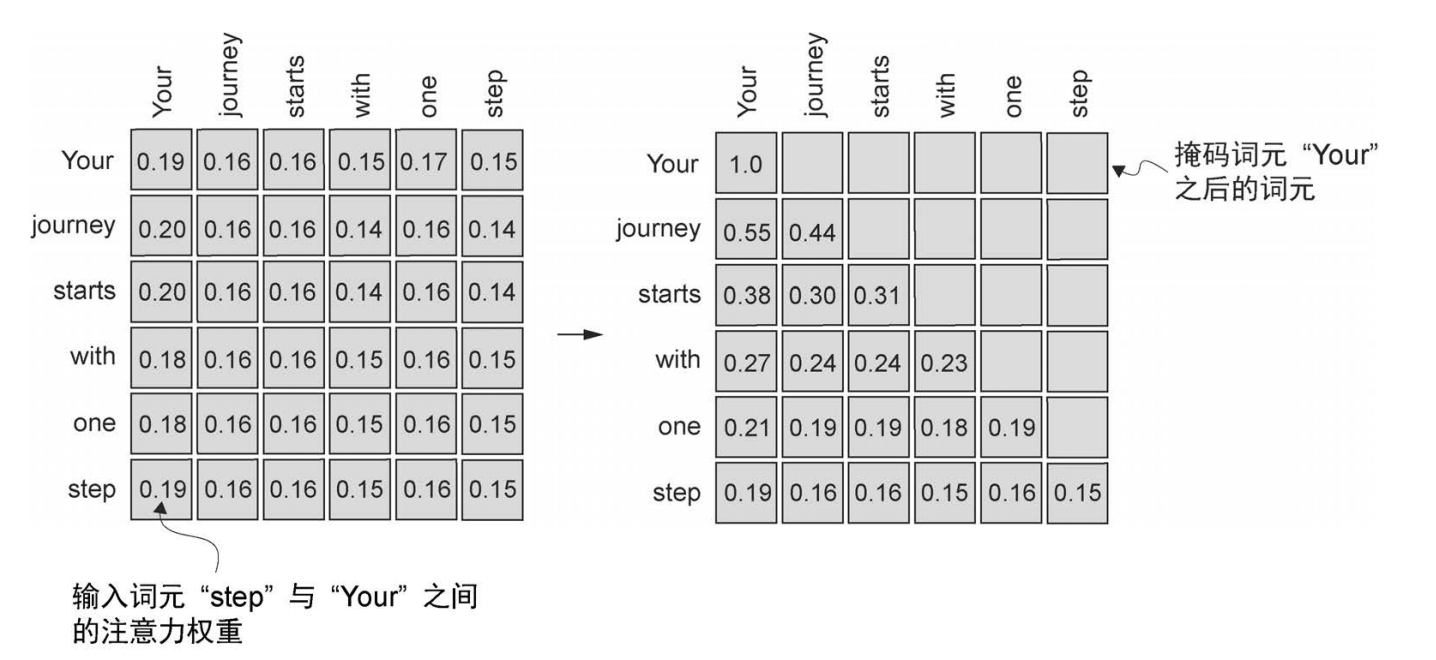

这实际上是在自注意力机制上做一个改动，用于屏蔽未来的token。由于我们在第二版自注意力类中已经能够计算注意力分数并得到注意力权重，接下来只需要在softmax之前对注意力分数加入因果掩码，就可以实现对未来位置的隐藏。

In [164]:
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
values = sa_v2.W_value(inputs)

attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / d_k**0.5, dim=-1)

In [165]:
attn_weights

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)

当前这个矩阵对应图中左侧的注意力权重矩阵，为了实现因果注意力，我们需要将主对角线以上的部分遮蔽，也就是禁止当前位置关注未来位置。一个常见做法是先构造一个掩码矩阵：对角线及其下方为有效位置，对角线以上为无效位置

可以使用`torch.tril`来生成这样的下三角掩码，它会保留对角线以下（含对角线）的元素，并将对角线以上的位置置为0，从而得到所需的三角形掩码。

In [166]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length,context_length))
              # 先生成一个元素全是1的T×T矩阵，再取下三角（含对角线）作为因果掩码，未来位置为 0
mask_simple

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])

接下来可以将注意力权重矩阵与该掩码矩阵逐元素相乘，从而把对角线以上（未来位置）的权重置为 0，实现遮蔽效果。

In [167]:
masked_simple = attn_weights * mask_simple # *表示逐元素相乘
masked_simple

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)

但是这样会带来一个新问题，掩码相乘后，每一行的权重之和不再等于 1。出于数值稳定和优化的考虑，让每一行仍然保持“总和为1”的归一化形式通常更有利。因此我们可以对掩码后的矩阵再做一次归一化处理，方法是按行求和，然后用逐元素除法把每个位置的值除以该行的总和，从而恢复每行权重和为1。

In [168]:
row_sums = masked_simple.sum(dim=-1,keepdim=True)
masked_simple_norm = masked_simple / row_sums
masked_simple_norm

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)

还有一种更简洁的做法可以得到同样的效果：与其先计算注意力权重再做掩码并重新归一化，不如在注意力分数尚未归一化时先对其进行掩码处理，然后直接对掩码后的分数应用 softmax。这样 softmax 会自动完成归一化，从而省去额外的归一化步骤。

In [169]:
mask = torch.triu(torch.ones(context_length, context_length),diagonal=1)
                            # diagonal=1 表示从主对角线“上面一条”开始保留上三角
masked = attn_scores.masked_fill(mask.bool(),-torch.inf)   
                            # 把 mask转成布尔类型：True表示要遮蔽的位置，False表示保留的位置
                            # 被遮蔽的位置填成-∞，这样softmax后这些位置权重会变成 0
masked

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)

-inf表示负无穷，是一个极小的数值。当我们在softmax中对其做指数运算时，$e^{−∞}$会趋近于0，因此对应位置的权重在归一化后也会变为0，从而达到被遮蔽的效果。

In [170]:
torch.exp(torch.tensor(float("-inf"))) #float("-inf") 的作用是把字符串"-inf"转成一个特殊的浮点数值：负无穷大

tensor(0.)

In [171]:
attn_weights = torch.softmax(masked / d_k**0.5, dim=-1)
attn_weights

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)

接下来我们再引入另一类遮罩，**失活掩码（dropout mask）**。dropout的做法是在注意力权重矩阵中随机选择一部分位置并将其置零，它是一种常见的正则化手段，用于降低过拟合。在注意力机制里应用dropout，可以促使模型不要过度依赖某几个固定位置，而是学会在不同位置之间更稳健地分配注意力。

在实现上，dropout 掩码通常会与因果掩码配合使用。因果掩码负责屏蔽对角线以上的未来位置，而 dropout 掩码则会在允许关注的范围内额外随机屏蔽一部分位置。因此，应用 dropout 后，对角线以上的区域仍然保持被遮蔽状态，但在对角线及其以下的区域会出现额外的随机“失活”，从而降低模型对某些注意力连接的依赖。


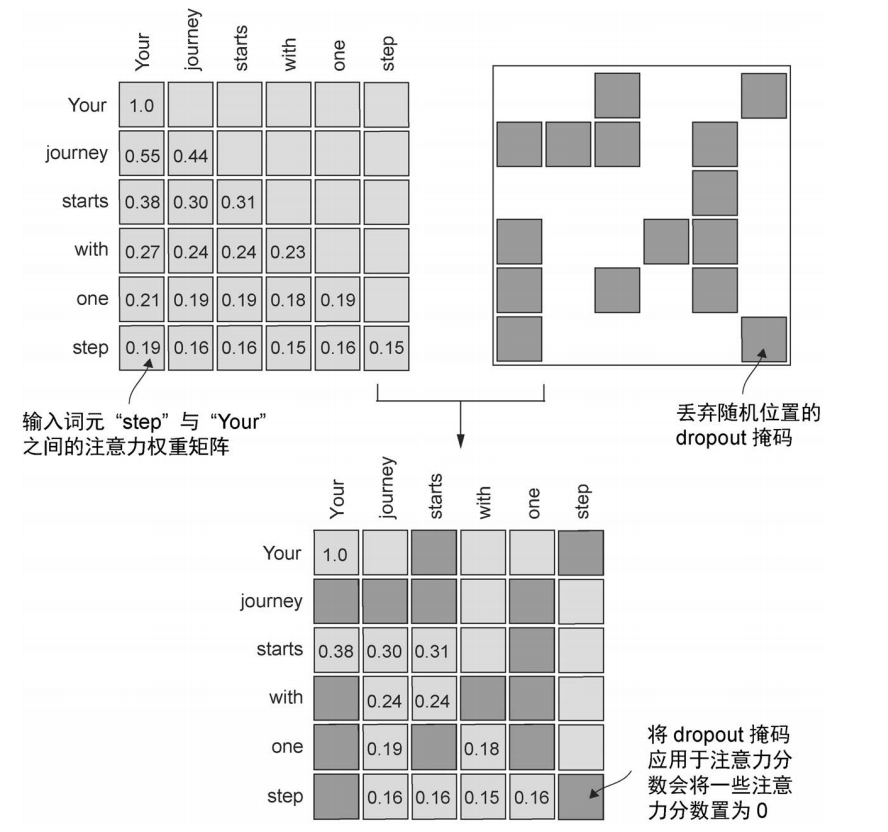

需要说明的是，在训练现代大语言模型时，注意力上的dropout已不如早期模型那样普遍使用。不过由于GPT-2的实现中使用了dropout，为了后续代码对齐与理解，这里仍作为一个概念进行介绍。

幸运的是，PyTorch 提供了现成的`Dropout`层，因此在现有计算流程中加入dropout非常直接。使用时只需要指定dropout率，例如这里设为 50%，表示会随机将一部分位置置零。

为了便于复现示例结果，我们也可以固定随机种子。不过需要注意的是，在不同系统或硬件环境下，dropout 的随机失活位置可能仍会出现细微差异，但这通常不影响整体理解与结论。

In [172]:
torch.manual_seed(123)

layer = torch.nn.Dropout(0.5)

首先创建一个形状为6×6的张量作为我们注意力权重的矩阵，使其与前面注意力矩阵的尺寸完全一致。

In [173]:
example = torch.ones(6,6)
example

tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])

现在我们可以对该张量应用 dropout，可以看到部分位置被随机置零。

In [174]:
layer(example)

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])

此时你会发现，除了被置零的位置外，其余数值会相应变大。这是因为 dropout 会对保留下来的数值做缩放，以保持整体尺度大致不变。接下来我们就可以将这个 dropout 层应用到注意力权重矩阵上。

In [175]:
layer(attn_weights)

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.4925, 0.4638, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.3941, 0.0000],
        [0.3869, 0.3327, 0.0000, 0.3084, 0.3331, 0.3058]],
       grad_fn=<MulBackward0>)

在前面的示例里，`inputs`表示一条输入序列，也就是一句话的token嵌入,共有6个token，每个token是3维向量，因此它的形状是[6, 3]。当我们把注意力机制、因果掩码和 dropout 等步骤整合进一个自注意力类之后，通常还需要考虑更常见的训练场景——一次同时处理多条输入，这就是所谓的**批次（batch）**。

为了演示batch的概念，我们可以用最简单的方法构造一个批次：把同一份inputs复制一份并堆叠在一起。这样就得到一个包含两条“样本”的输入张量，其形状会变成 [2, 6, 3]。这里最前面的2就是批次大小，表示一次同时送入模型的序列数量；后面的6和3分别仍然表示序列长度和嵌入维度。

In [176]:
batch = torch.stack((inputs,inputs),dim=0)
batch.shape

torch.Size([2, 6, 3])

In [180]:
import torch.nn as nn

class CausalAttention(nn.Module):  
    
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False): 
        super(). __init__()          
        self.W_query = torch.nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = torch.nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = torch.nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = torch.nn.Dropout(dropout)
        self.register_buffer("mask",torch.triu(torch.ones(context_length,context_length), diagonal=1))
                            # 注册因果掩码为“缓冲器（buffer）”
                            # 目的：mask 不是可训练参数，但希望它随模型一起移动到 GPU，并随模型保存/加载
                            # torch.triu(..., diagonal=1) 生成上三角（对角线以上为 1），表示“未来位置需要被遮蔽”
    def forward(self,x):
        b, num_tokens, d_in = x.shape
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2) 
        attn_scores.masked_fill_( 
                             # masked_fill_ 是“原地操作”（带下划线），直接修改 attn_scores，不创建副本
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf) 
                             # mask.bool() 把 0/1 变成 False/True：True 的位置表示“要遮蔽”
                             # 被遮蔽的位置填 -inf，softmax 后这些位置的权重会变成 0
        attn_weights = torch.softmax( 
            attn_scores / keys.shape[-1]**0.5, dim=-1 
        )
        attn_weights = self.dropout(attn_weights) 
        
        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(789)

context_length = batch.shape[1]
dropout = 0.0
ca = CausalAttention(d_in, d_out, context_length, dropout)
ca(batch)                   # 前向计算：输入 batch，输出每个 token 的上下文向量，形状 (b, num_tokens, d_out)        

tensor([[[-0.0872,  0.0286],
         [-0.0991,  0.0501],
         [-0.0999,  0.0633],
         [-0.0983,  0.0489],
         [-0.0514,  0.1098],
         [-0.0754,  0.0693]],

        [[-0.0872,  0.0286],
         [-0.0991,  0.0501],
         [-0.0999,  0.0633],
         [-0.0983,  0.0489],
         [-0.0514,  0.1098],
         [-0.0754,  0.0693]]], grad_fn=<UnsafeViewBackward0>)

`register_buffer("mask", ...)` 是把`mask`这个张量登记为“模型的一部分固定数据”。它不是要训练的参数，所以不会被优化器更新，但它会被 PyTorch当作模型内部的“长期成员”来管理。
这样做最实用的好处是,以后把模型搬到GPU时，PyTorch会自动把模型的参数搬过去,注册成`buffer`的`mask`也会一起搬过去，避免出现“模型在 GPU、mask 还在 CPU”这种不匹配的问题。同时，`buffer`也会跟着模型一起保存/加载（进`state_dict`），但不会参与训练更新。

掩码放在`__init__`里提前生成，是为了避免在每次`forward`时重复创建同一份矩阵。因果掩码只与最大上下文长度`context_length` 有关，本身不需要随着输入或训练动态变化，因此在初始化阶段生成一次即可。前向计算时，输入序列的实际长度可能是`num_tokens`（可能小于`context_length`），所以代码用`self.mask[:num_tokens, :num_tokens]` 截取出与当前注意力分数矩阵同样大小的那一块掩码，既保证尺寸对齐，也避免多余计算。

在前向传播里，`attn_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)`这一步是在“隐藏未来token”。`self.mask.bool()`会把掩码从 0/1 变成 False/True，其中True对应对角线以上的位置，也就是不允许关注的未来位置。`masked_fill_`会把这些True位置上的注意力分数直接替换成-inf。这样做的原因是后面要接`softmax`，所以这些位置在`softmax`后的注意力权重会变成0，从而模型就无法把注意力分配到未来token上。这里的`masked_fill_`末尾带下划线表示原地操作，含义是直接修改现有的`attn_scores`，不额外创建副本，通常更省内存、更高效。

### 3.6 多头注意力

在前面的例子中，我们的输入张量是一个 6×3 的矩阵，表示序列中有 6 个 token，每个 token 被映射为 3 维嵌入向量。通过单头注意力（包含因果掩码）计算后，我们得到一个 
6×2 的上下文张量，也就是序列长度仍然是 6，只是每个 token 的表示从 3 维变成了 2 维。

我们前面已经实现了带因果掩码的自注意力机制。接下来要引入的是**多头注意力（multi-head attention）**。多头注意力的核心思路是并行使用多个自注意力头，从同一段输入中提取不同类型的信息。每个注意力头都有各自独立的一组权重参数，初始化不同，训练过程中也会学到略有差异的关注模式与特征表示。将多个头的结果汇合后，模型能够获得更丰富、更具多样性的输入信息表达，而不局限于单一注意力头所捕捉到的模式。

之前我们只得到一份上下文表示（可以记作$Z_1$），现在我们希望并行计算两份上下文表示（$Z_1$和$Z_2$），也就是使用两个注意力头。注意力头的数量是一个可设置的超参数。每个头都会输出一个 6×2 的上下文张量，最后我们把这两个张量在最后一维拼接起来，于是得到一个新的输出张量，形状为 6×4，因为输出维度从 2 变成了 2×2=4。

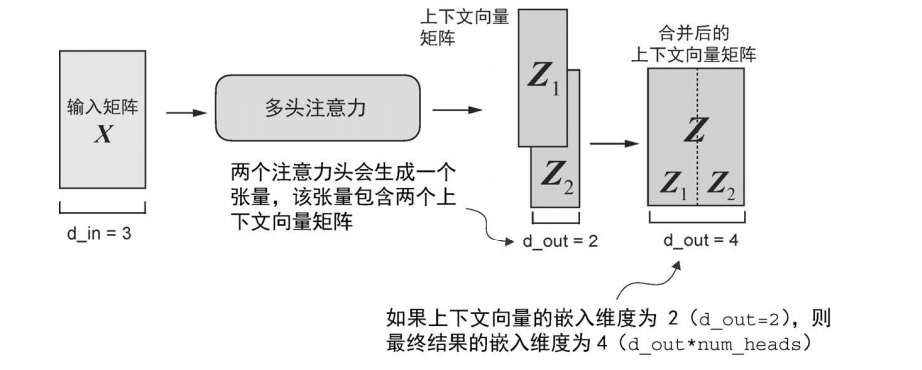

接下来我们将创建一个用于封装多头注意力的类，可以把它理解为“多头注意力的外层包装”。在构造函数`__init__`中，我们会初始化所需数量的注意力头，例如这里创建两个注意力头。

随后在前向传播`forward`中，做法很直接，将同一个输入依次送入每个注意力头，得到每个头各自的输出。实现上通常会把这些单头注意力模块放在一个列表（或模块列表）中，然后在`forward`里对这个列表进行迭代，逐个调用每个头来完成计算。

In [184]:
class MultiHeadAttentionWrapper(nn.Module):
    """
    多头注意力的“封装层”。
    思路：创建多个独立的注意力头（这里用 CausalAttention 作为单头），
    每个头都对同一份输入做一次注意力计算，最后把各头输出拼接起来。
    """
    def __init__(self, d_in, d_out, context_length, dropout, num_heads=2, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList([ #创建 num_heads 个 CausalAttention 实例，每个实例都有自己独立的参数（W_query/W_key/W_value）
        CausalAttention(d_in, d_out, context_length, dropout,qkv_bias) for _ in range(num_heads)
        ])

    def forward(self,x):
        """
        前向传播：把同一个输入 x 分别送进每个注意力头，然后把输出拼接。
        输入 x 形状: (b, num_tokens, d_in)
        单个头输出形状: (b, num_tokens, d_out)
        拼接后输出形状: (b, num_tokens, d_out * num_heads)
        """
        return torch.cat([head(x) for head in self.heads], dim=-1)
                         # [head(x) for head in self.heads] 会得到一个列表：
                         # 里面每个元素都是一个注意力头的输出张量，形状都是 (b, num_tokens, d_out)

torch.manual_seed(123)

context_length = batch.shape[1]
d_in, d_out = 3,2

mha = MultiHeadAttentionWrapper(d_in, d_out, context_length, dropout=0.0, num_heads=2)
mha(batch)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)

接下来还有一种更高效的多头注意力实现方式。前面那种“堆叠多个注意力头”的写法，需要在`forward`里逐个调用每个头，本质上是顺序执行，难以充分利用GPU的并行能力，因此效率不够理想。

更常见的做法是用一套更大的权重矩阵一次性生成所有头的Q/K/V，而不是为每个头各自建一套模块。实现上通常会先确保`d_out`能被头数 `num_heads`整除（用`assert`检查），然后定义每个头的维度`head_dim = d_out // num_heads`。这样我们可以用一次矩阵乘法得到“合并后的” query（以及 key、value），其最后一维包含了所有头的信息，再按照`num_heads`和`head_dim`把它拆分成多个头的表示。之所以要求可整除，就是为了保证拆分时维度对齐且不丢失信息。

In [192]:
class MultiHeadAttention(nn.Module):

    """
    更高效的多头注意力（带因果掩码）
    一次性用大矩阵生成所有头的 Q/K/V，再 reshape+transpose 拆成多个头并行计算
    最后把所有头的结果拼回 (b, num_tokens, d_out)
    """ 
    
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0)
        
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # 总输出维度 d_out 必须能被头数 num_heads 整除
                                           # 这样每个头的维度 head_dim 才是整数，便于 reshape 拆分

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # 将拼接后的多头输出再做一次线性变换
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x) 
        queries = self.W_query(x)
        values = self.W_value(x)
        
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)       
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        
        """
        拆分成多头，把最后一维 d_out 拆成 (num_heads, head_dim)
        形状变为 (b, num_tokens, num_heads, head_dim)
        """
        
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        """
        交换维度，把 num_heads 提到前面，方便并行计算注意力
        形状变为 (b, num_heads, num_tokens, head_dim)
        """

        attn_scores = queries @ keys.transpose(2, 3)  
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        attn_scores.masked_fill_(mask_bool, -torch.inf)
        
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2) # 把维度换回 (b, T, h, hd)，再把 h 和 hd 合并回 d_out
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

torch.manual_seed(123)

batch_size, context_length, d_in = batch.shape
d_out = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)

context_vecs = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])
